In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm.auto import tqdm

from libs.DataLoader import Loader
from libs.constants import *

In [2]:
# loader = Loader('ur0.01_ir0.01', content_embedding_size=64, batch_size=1_000_000)
# (train_df, val_df), users_df, items_df = loader.load_data(convert_to_pandas=True)

  0%|          | 0/2 [00:00<?, ?it/s]

Users: 89_371 -> 10_487
Items: 120_415 -> 120_415
Train: 3_720_328 -> 1_832_911
Val: 170_111 -> 58_017
Train: 1_832_911 Val: 58_017 Users: 10_487 Items: 120_415


In [ ]:
loader = Loader('ur0.01_ir0.01', content_embedding_size=64, batch_size=1_000_000)
(train_df, val_df), users_df, items_df = loader.load_data(convert_to_pandas=True, filter_data=False)

In [4]:
df = train_df.merge(items_df, on=ITEM)[[USER, ITEM, AUTHOR, TARGET]]

In [23]:
users, items, authors, authors_users, authors_items = [
    grouped.agg(
        positive=(TARGET, lambda x: (x>0).sum()),
        negative=(TARGET, lambda x: (x<0).sum()),
        count=(TARGET, 'count'),
        score=(TARGET, 'sum')
    )
    for grouped in tqdm([
        df.groupby(USER), df.groupby(ITEM), df.groupby([AUTHOR]),
        df.groupby([AUTHOR, USER]), df.groupby([AUTHOR, ITEM])
    ])
]

  0%|          | 0/5 [00:00<?, ?it/s]

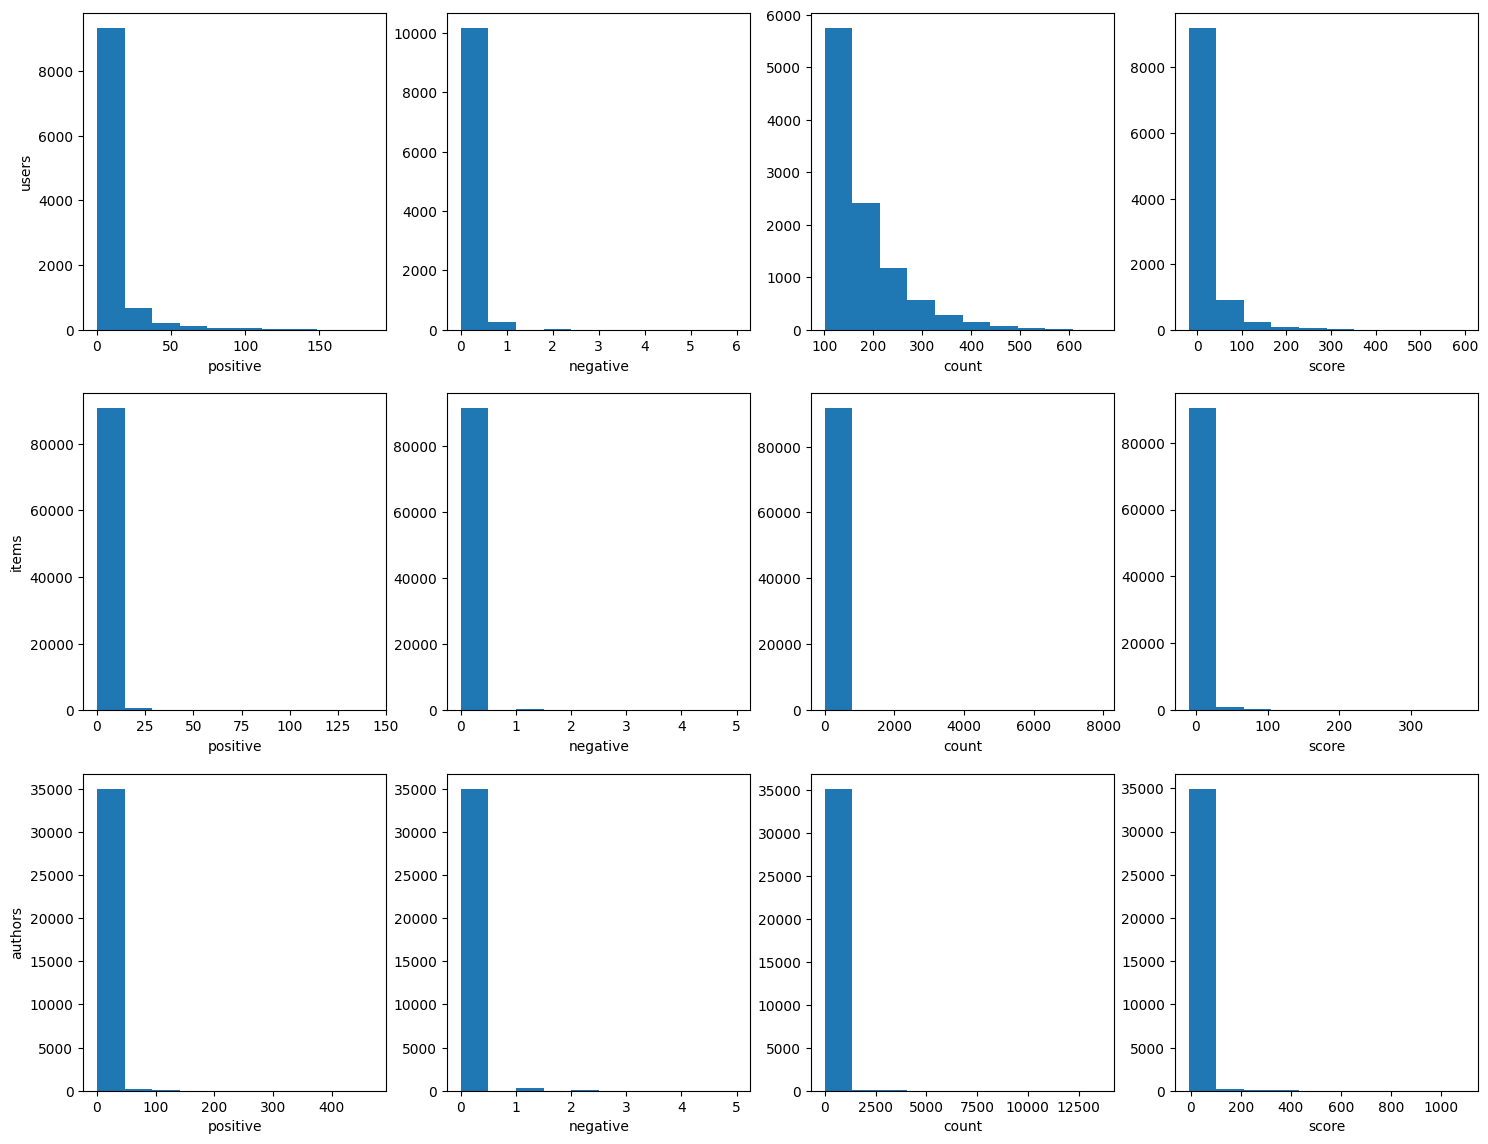

In [82]:
fig, axes = plt.subplots(3, 4)
fig.set_size_inches(18, 14)
for i, (data, name) in enumerate(zip([users, items, authors], ["users", "items", "authors"])):
    axes[i][0].set_ylabel(name)
    for j, col in enumerate(['positive', 'negative', 'count', 'score']):
        X = data[col]
        axes[i][j].set_xlabel(col)
        axes[i][j].hist(X)

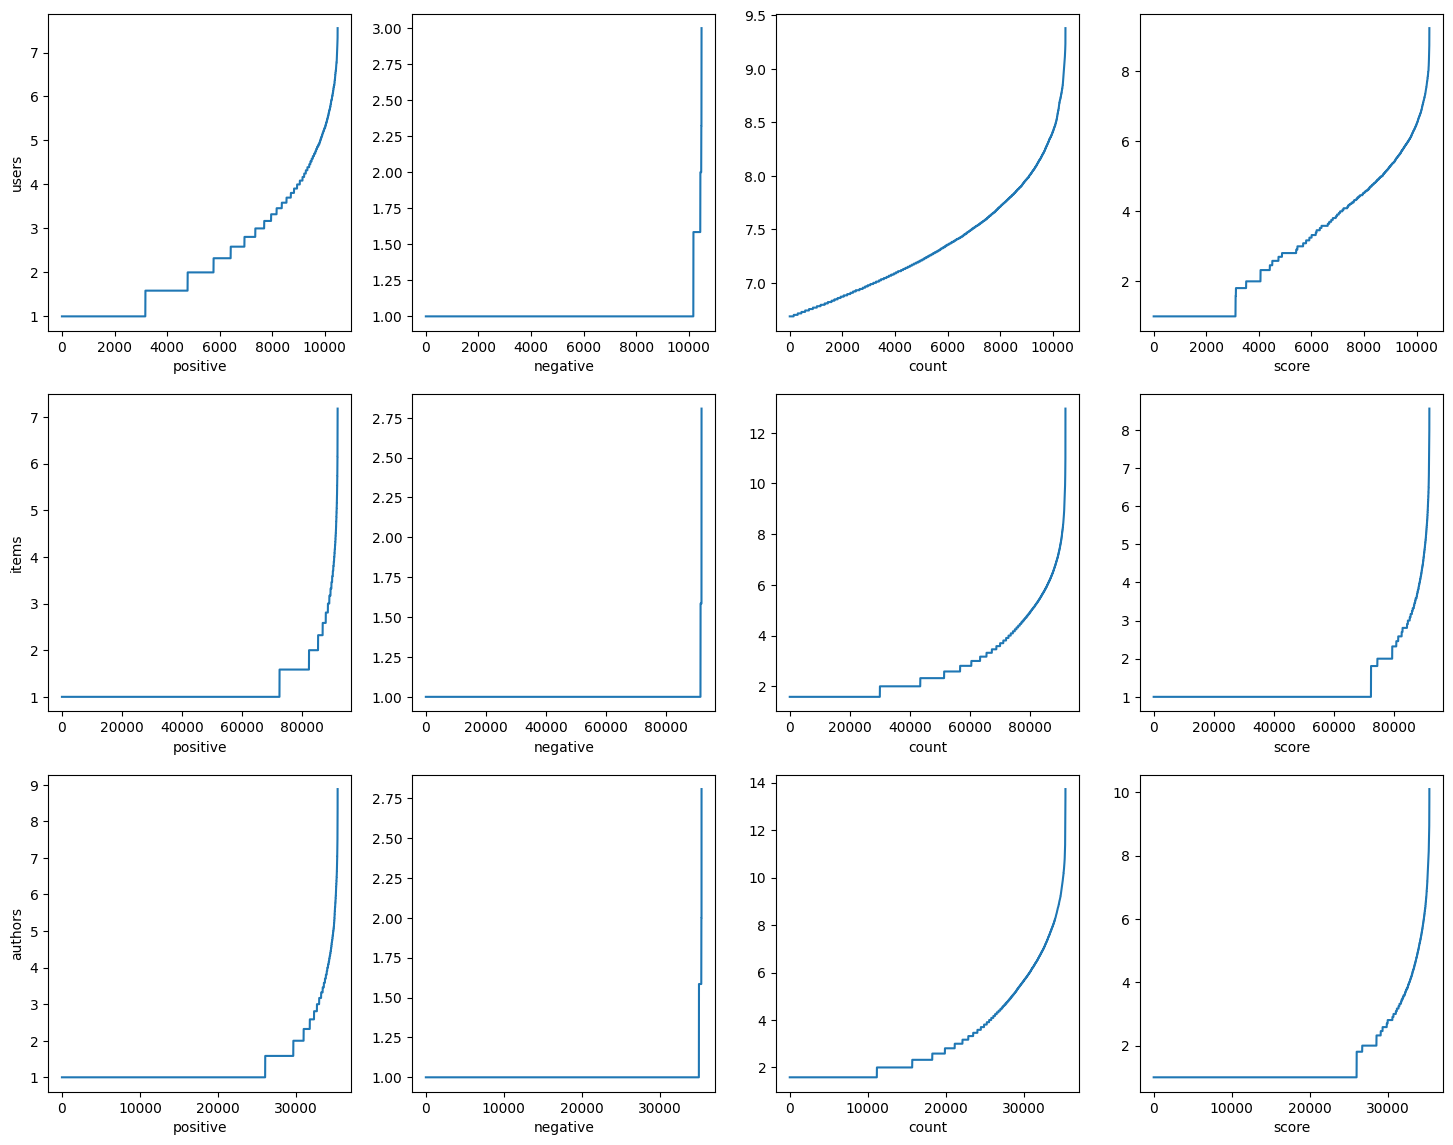

In [83]:
fig, axes = plt.subplots(3, 4)
fig.set_size_inches(18, 14)
for i, (data, name) in enumerate(zip([users, items, authors], ["users", "items", "authors"])):
    axes[i][0].set_ylabel(name)
    for j, col in enumerate(['positive', 'negative', 'count', 'score']):
        axes[i][j].set_xlabel(col)
        axes[i][j].plot(sorted(np.log2(2+data[col].abs())))

In [104]:
users_filtered = users[
    (users["count"] > 100)  # Не выгодно показывать клипы юзерам, которые не интересуются клипами
    & (users["positive"].mean() > 0.05)  # Не выгодно показывать клипы юзерам которые смотрят, но не лайкают
    & (users["negative"].mean() < 0.05)  # Не выгодно показывать клипы юзерам, которые много дизлайкают
]

items_filtered = items  # Фильтровать айтемы и авторов не имеет смысла, мы предсказываем для всех данных айтемов

print(f"Users: {len(users):_} -> {len(users_filtered):_}")
print(f"Items: {len(items):_} -> {len(items_filtered):_}")

Users: 89_371 -> 10_487
Items: 120_415 -> 120_415


In [108]:
users_df_filtered = users_df.merge(users_filtered[[]], left_on=USER, right_index=True)
assert len(users_filtered) == len(users_df_filtered) and set(users_df_filtered.columns) == set(users_df.columns)

items_df_filtered = items_df.merge(items_filtered[[]], left_on=ITEM, right_index=True)
assert len(items_filtered) == len(items_df_filtered) and set(items_df_filtered.columns) == set(items_df.columns)